In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter


In [2]:
os.makedirs("figures", exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

WAR_START = pd.Timestamp("2022-02-24")

COLORS = {
    "Drone": "#d73027",
    "Artillery": "#4575b4",
    "Armored warfare": "#4d4d4d",
    "Airstrike": "#fdae61"
}


In [3]:
ukr_database = pd.read_csv(
    "data/uadatabase.csv",
    low_memory=False
)

event2022 = pd.read_csv(
    "data/event_1pd_latest_2022.csv",
    low_memory=False
)
event2023 = pd.read_csv(
    "data/event_1pd_latest_2023.csv",
    low_memory=False
)
event2024 = pd.read_csv(
    "data/event_1pd_latest_2024.csv",
    low_memory=False
)
event2025 = pd.read_csv(
    "data/event_1pd_latest_2025.csv",
    low_memory=False
)
event2026 = pd.read_csv(
    "data/event_1pd_latest_2026.csv",
    low_memory=False
)

poteru = pd.read_csv(
    "data/poteru_rus.csv",
    low_memory=False
)

rus_officers = pd.read_csv(
    "data/rus_ofc_kia.csv",
    low_memory=False
)



In [4]:
events = pd.concat(
    [
        event2022,
        event2023,
        event2024,
        event2025,
        event2026
    ],
    ignore_index=True
)

raw_dates = (
    events["date"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

compact_dates = pd.to_datetime(
    raw_dates,
    format="%Y%m%d",
    errors="coerce"
)

formatted_dates = pd.to_datetime(
    raw_dates,
    errors="coerce"
)

events["date"] = compact_dates.fillna(formatted_dates)

events = events[
    events["date"].notna()
    & (events["date"] >= WAR_START)
].copy()

events["month"] = (
    events["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

binary_columns = [
    "t_mil_b",
    "t_uav_b",
    "t_artillery_b",
    "t_armor_b",
    "t_airstrike_b",
    "t_milcas_b",
    "t_civcas_b"
]

for column in binary_columns:
    events[column] = (
        pd.to_numeric(events[column], errors="coerce")
        .fillna(0)
        .gt(0.5)
    )

military_events = events.loc[
    events["t_mil_b"]
].copy()

tactics = {
    "Drone": "t_uav_b",
    "Artillery": "t_artillery_b",
    "Armored warfare": "t_armor_b",
    "Airstrike": "t_airstrike_b"
}

print("Total events:", len(events))
print("Military events:", len(military_events))
print("Missing months:", military_events["month"].isna().sum())
print(
    "Date range:",
    events["date"].min(),
    "to",
    events["date"].max()
)


Total events: 407857
Military events: 307793
Missing months: 0
Date range: 2022-02-24 00:00:00 to 2026-07-28 00:00:00


Months in graph: 54
               Drone  Artillery  Armored warfare  Airstrike
month                                                      
2022-02-01  2.303038  26.166183         2.492313   6.567874
2022-03-01  2.063173  26.981821         2.161577   5.730528
2022-04-01  2.030786  29.002113         1.469946   5.000317
2022-05-01  1.860649  30.687837         1.105211   4.186647
2022-06-01  1.836083  32.680208         0.830770   4.339485


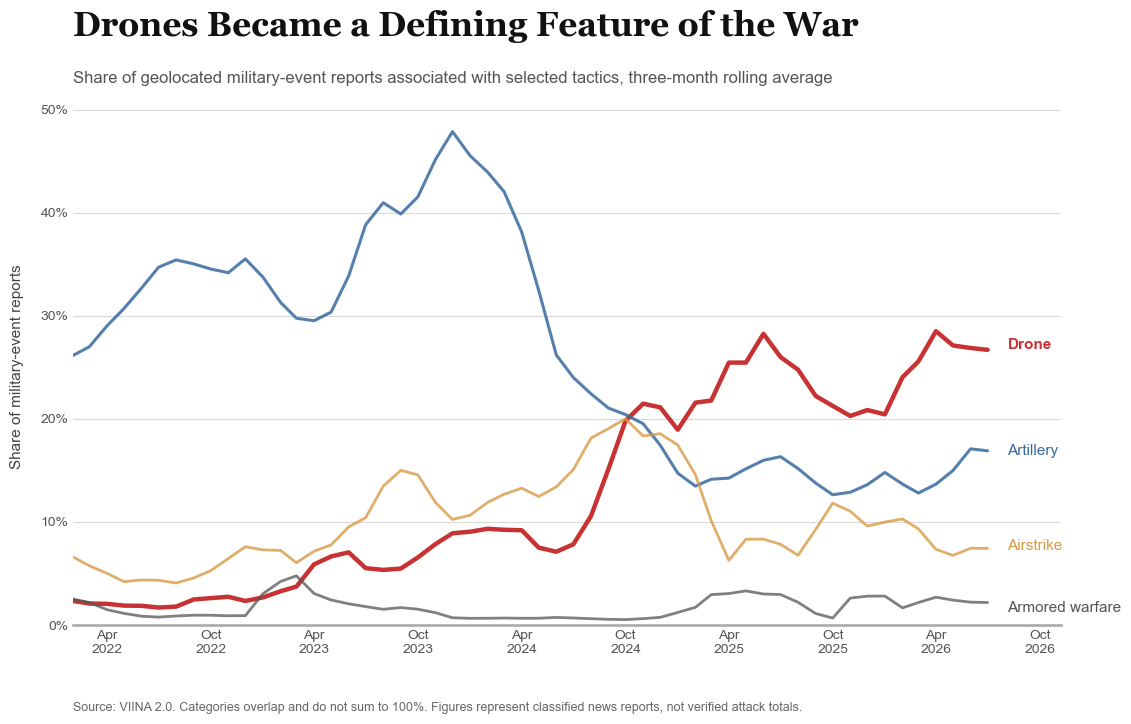

In [5]:
monthly_total = (
    military_events
    .groupby("month")
    .size()
)

tactic_share = pd.DataFrame(
    index=monthly_total.index
)

for label, column in tactics.items():
    monthly_count = (
        military_events
        .groupby("month")[column]
        .sum()
    )

    tactic_share[label] = (
        monthly_count
        .div(monthly_total)
        .mul(100)
    )

tactic_share_smoothed = tactic_share.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

print("Months in graph:", len(tactic_share_smoothed))
print(tactic_share_smoothed.head())

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, ax = plt.subplots(figsize=(13, 7.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plot_styles = {
    "Drone": {
        "color": "#C83232",
        "linewidth": 3.2,
        "alpha": 1.0
    },
    "Artillery": {
        "color": "#376A9F",
        "linewidth": 2.2,
        "alpha": 0.85
    },
    "Armored warfare": {
        "color": "#555555",
        "linewidth": 2.0,
        "alpha": 0.75
    },
    "Airstrike": {
        "color": "#D99A45",
        "linewidth": 2.0,
        "alpha": 0.8
    }
}

for tactic in tactic_share_smoothed.columns:
    style = plot_styles[tactic]

    ax.plot(
        tactic_share_smoothed.index,
        tactic_share_smoothed[tactic],
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"]
    )


label_offsets = {
    "Drone": 0.5,
    "Artillery": 0.0,
    "Armored warfare": -0.5,
    "Airstrike": 0.3
}

last_date = tactic_share_smoothed.index.max()
label_date = last_date + pd.Timedelta(days=35)

for tactic in tactic_share_smoothed.columns:
    final_value = (
        tactic_share_smoothed[tactic]
        .dropna()
        .iloc[-1]
    )

    ax.text(
        label_date,
        final_value + label_offsets[tactic],
        tactic,
        color=plot_styles[tactic]["color"],
        fontsize=11,
        fontfamily="Arial",
        fontweight=(
            "bold" if tactic == "Drone" else "normal"
        ),
        va="center"
    )

fig.suptitle(
    "Drones Became a Defining Feature of the War",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=24,
    fontweight="bold",
    fontfamily="Georgia",
    color="#111111"
)

ax.set_title(
    "Share of geolocated military-event reports associated "
    "with selected tactics, three-month rolling average",
    loc="left",
    fontsize=12,
    fontfamily="Arial",
    color="#555555",
    pad=18
)

ax.set_ylabel(
    "Share of military-event reports",
    fontsize=11,
    fontfamily="Arial",
    color="#444444",
    labelpad=12
)

ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=0
    )
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.set_xlim(
    tactic_share_smoothed.index.min(),
    last_date + pd.Timedelta(days=130)
)

ax.set_ylim(bottom=0)

ax.grid(
    axis="y",
    color="#D9D9D9",
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

for spine in [
    "top",
    "right",
    "left"
]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=10,
    colors="#555555"
)

legend = ax.get_legend()

if legend is not None:
    legend.remove()

fig.text(
    0.08,
    0.035,
    "Source: VIINA 2.0. Categories overlap and do not sum to 100%. "
    "Figures represent classified news reports, not verified attack totals.",
    ha="left",
    fontsize=9,
    fontfamily="Arial",
    color="#666666"
)

plt.subplots_adjust(
    left=0.08,
    right=0.84,
    top=0.84,
    bottom=0.15
)


plt.savefig(
    "figures/01_viina_tactic_shares_editorial.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Latest date in dataset: 2026-05-31 00:00:00

Quarterly totals:
            Junior officers  Senior officers  Generals and supreme officers  \
quarter                                                                       
2022-01-01              356              128                              1   
2022-04-01              366              124                              2   
2022-07-01              353              129                              0   
2022-10-01              265              117                              0   
2023-01-01              331               85                              0   
2023-04-01              293               95                              1   
2023-07-01              349              100                              0   
2023-10-01              391              104                              1   
2024-01-01              393               85                              0   
2024-04-01              399               89                        

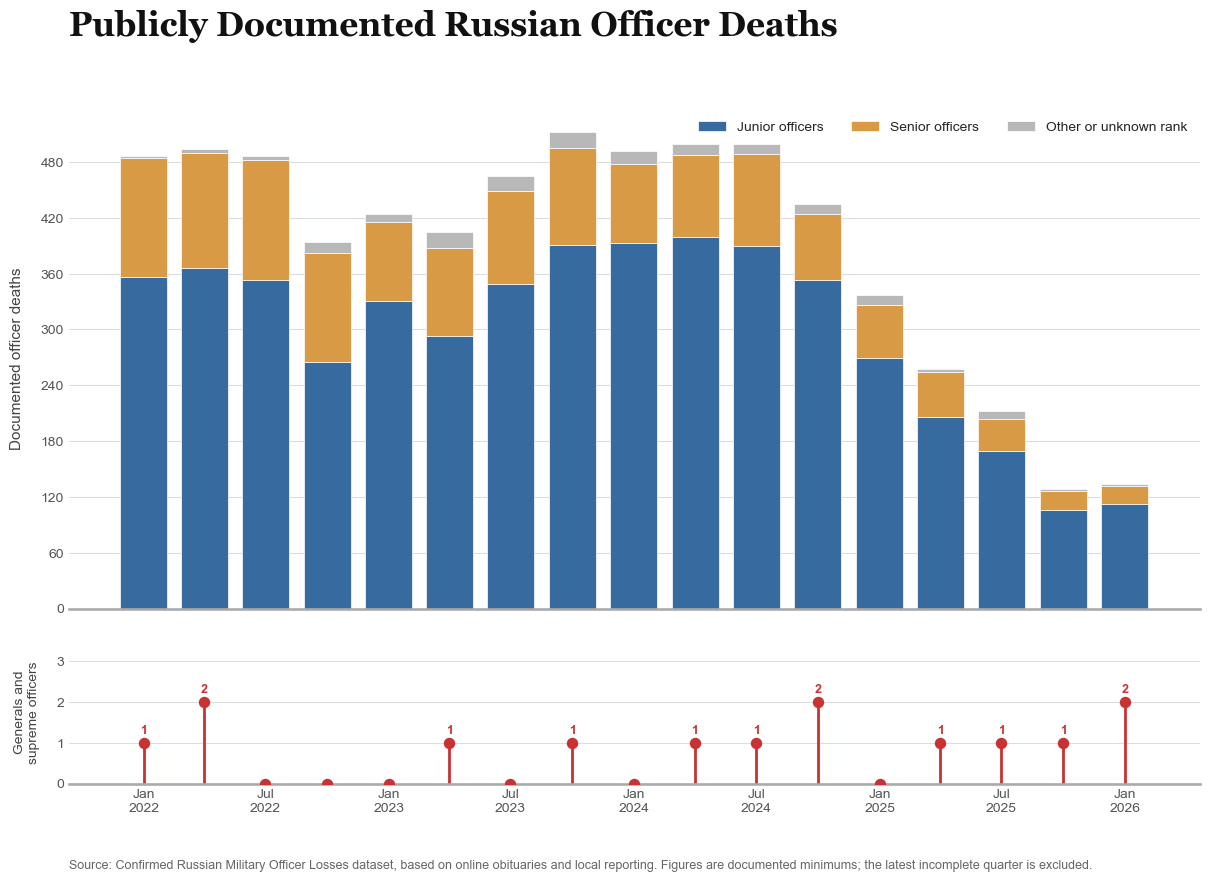

In [6]:
from matplotlib.ticker import MaxNLocator

rus_officers["Date"] = pd.to_datetime(
    rus_officers["Date"],
    errors="coerce"
)

rus_officers = rus_officers.loc[
    rus_officers["Date"].notna()
    & (rus_officers["Date"] >= WAR_START)
].copy()

rank_columns = [
    "JuniorOfficers",
    "SeniorOfficers",
    "SupremeAndGeneralOfficers",
    "Other_UnknownRank"
]

for column in rank_columns:
    rus_officers[column] = pd.to_numeric(
        rus_officers[column],
        errors="coerce"
    ).fillna(0)

rus_officers["quarter"] = (
    rus_officers["Date"]
    .dt.to_period("Q")
    .dt.to_timestamp()
)


# ============================================================
# CALCULATE QUARTERLY TOTALS
# ============================================================

quarterly_officers = (
    rus_officers
    .groupby("quarter")[rank_columns]
    .sum()
    .rename(columns={
        "JuniorOfficers": "Junior officers",
        "SeniorOfficers": "Senior officers",
        "SupremeAndGeneralOfficers":
            "Generals and supreme officers",
        "Other_UnknownRank": "Other or unknown rank"
    })
    .sort_index()
)


# ============================================================
# REMOVE LATEST INCOMPLETE QUARTER
# ============================================================

latest_data_date = rus_officers["Date"].max()
latest_data_quarter = latest_data_date.to_period("Q")

quarterly_officers = quarterly_officers.loc[
    quarterly_officers.index.to_period("Q")
    < latest_data_quarter
].copy()

print("Latest date in dataset:", latest_data_date)
print("\nQuarterly totals:")
print(quarterly_officers)

print("\nTotal documented deaths by rank:")
print(quarterly_officers.sum())


# ============================================================
# DEFINE RANK GROUPS
# ============================================================

main_ranks = [
    "Junior officers",
    "Senior officers",
    "Other or unknown rank"
]

general_rank = "Generals and supreme officers"

rank_colors = {
    "Junior officers": "#376A9F",
    "Senior officers": "#D99A45",
    "Other or unknown rank": "#B8B8B8"
}


# ============================================================
# FONT SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.5, 1]
    }
)

fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")


# ============================================================
# TOP PANEL: OTHER OFFICER RANKS
# ============================================================

bottom = np.zeros(
    len(quarterly_officers)
)

for rank in main_ranks:
    axes[0].bar(
        quarterly_officers.index,
        quarterly_officers[rank],
        bottom=bottom,
        width=70,
        color=rank_colors[rank],
        label=rank,
        edgecolor="white",
        linewidth=0.5
    )

    bottom += quarterly_officers[
        rank
    ].to_numpy()

axes[0].set_ylabel(
    "Documented officer deaths",
    fontsize=11,
    color="#444444",
    labelpad=12
)

axes[0].set_ylim(bottom=0)

axes[0].yaxis.set_major_locator(
    MaxNLocator(integer=True)
)

axes[0].legend(
    frameon=False,
    ncol=3,
    loc="upper right",
    fontsize=10
)


# ============================================================
# BOTTOM PANEL: GENERALS AND SUPREME OFFICERS
# ============================================================

general_values = quarterly_officers[
    general_rank
]

axes[1].vlines(
    quarterly_officers.index,
    ymin=0,
    ymax=general_values,
    color="#C83232",
    linewidth=2
)

axes[1].scatter(
    quarterly_officers.index,
    general_values,
    color="#C83232",
    s=45,
    zorder=3
)

# Add a label above every nonzero value.
for date, value in general_values.items():
    if value > 0:
        axes[1].text(
            date,
            value + 0.15,
            f"{int(value)}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#C83232",
            fontweight="bold"
        )

axes[1].set_ylabel(
    "Generals and\nsupreme officers",
    fontsize=10,
    color="#444444",
    labelpad=12
)

axes[1].set_ylim(
    0,
    max(
        general_values.max() + 1.5,
        3
    )
)

axes[1].yaxis.set_major_locator(
    MaxNLocator(integer=True)
)

axes[1].set_xlabel("")


# ============================================================
# TITLE AND SUBTITLE
# ============================================================

fig.suptitle(
    "Publicly Documented Russian Officer Deaths",
    x=0.09,
    y=0.98,
    ha="left",
    fontsize=24,
    fontweight="bold",
    fontfamily="Georgia",
    color="#111111"
)

# ============================================================
# DATE AXIS
# ============================================================

axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)


# ============================================================
# EDITORIAL FORMATTING
# ============================================================

for ax in axes:
    ax.grid(
        axis="y",
        color="#DDDDDD",
        linewidth=0.8
    )

    ax.grid(
        axis="x",
        visible=False
    )

    ax.set_axisbelow(True)

    for spine in [
        "top",
        "right",
        "left"
    ]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color(
        "#AAAAAA"
    )

    ax.tick_params(
        axis="both",
        which="both",
        length=0,
        colors="#555555"
    )


# ============================================================
# SOURCE NOTE
# ============================================================

fig.text(
    0.09,
    0.025,
    "Source: Confirmed Russian Military Officer Losses dataset, "
    "based on online obituaries and local reporting. Figures are "
    "documented minimums; the latest incomplete quarter is excluded.",
    ha="left",
    fontsize=9,
    fontfamily="Arial",
    color="#666666"
)


# ============================================================
# SPACING, SAVE AND DISPLAY
# ============================================================

plt.subplots_adjust(
    left=0.09,
    right=0.96,
    top=0.87,
    bottom=0.12,
    hspace=0.10
)

plt.savefig(
    "figures/02_russian_officer_deaths_two_panel.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Total Ukrainian records: 212,867
Records with usable ages: 207,000
Age coverage: 97.2%
Median documented age: 40.1


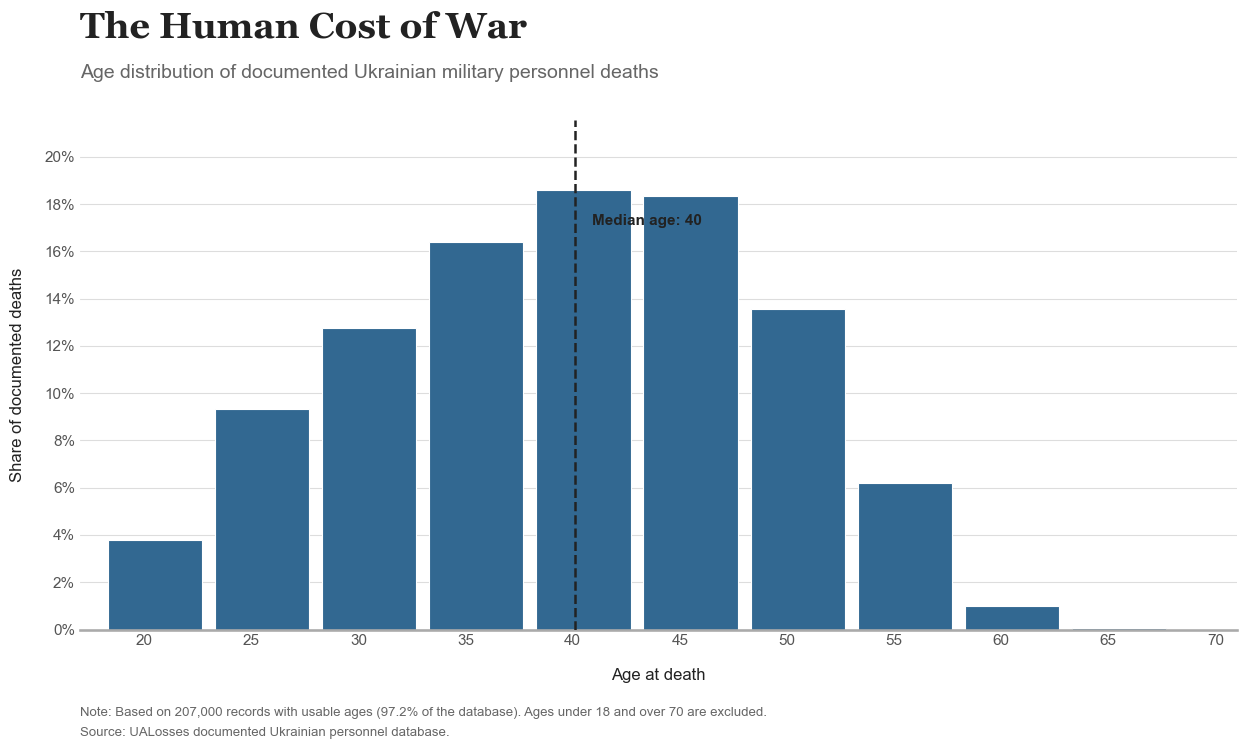

In [7]:
from matplotlib.ticker import PercentFormatter, MultipleLocator

ukr_age_data = ukr_database.copy()

ukr_age_data["DateEvent_clean"] = pd.to_datetime(
    ukr_age_data["DateEvent"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

ukr_age_data["DateBirth_clean"] = pd.to_datetime(
    ukr_age_data["DateBirth"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

ukr_age_data["Age_clean"] = pd.to_numeric(
    ukr_age_data["Age"],
    errors="coerce"
)

calculated_age = (
    ukr_age_data["DateEvent_clean"]
    - ukr_age_data["DateBirth_clean"]
).dt.days / 365.25

ukr_age_data["Age_clean"] = (
    ukr_age_data["Age_clean"]
    .fillna(calculated_age)
)

ukr_ages = (
    ukr_age_data.loc[
        ukr_age_data["Age_clean"].between(18, 70),
        "Age_clean"
    ]
    .dropna()
    .astype(float)
)

total_records = len(ukr_database)
known_age_records = len(ukr_ages)
age_coverage = known_age_records / total_records
median_age = ukr_ages.median()

print("Total Ukrainian records:", f"{total_records:,}")
print("Records with usable ages:", f"{known_age_records:,}")
print("Age coverage:", f"{age_coverage:.1%}")
print("Median documented age:", round(median_age, 1))

age_bins = np.arange(18, 74, 5)

age_counts, bin_edges = np.histogram(
    ukr_ages,
    bins=age_bins
)

# Convert counts to percentages
age_percentages = (
    age_counts / age_counts.sum()
) * 100

bin_centers = (
    bin_edges[:-1] + bin_edges[1:]
) / 2

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

UKRAINE_BLUE = "#326891"
TEXT_COLOR = "#222222"
SECONDARY_TEXT = "#666666"
GRID_COLOR = "#dddddd"

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.bar(
    bin_centers,
    age_percentages,
    width=4.4,
    color=UKRAINE_BLUE,
    edgecolor="white",
    linewidth=0.8
)

# Median line
ax.axvline(
    median_age,
    color=TEXT_COLOR,
    linewidth=1.8,
    linestyle="--",
    zorder=4
)

ax.text(
    median_age + 0.8,
    max(age_percentages) * 0.92,
    f"Median age: {median_age:.0f}",
    fontsize=11,
    fontweight="bold",
    color=TEXT_COLOR,
    ha="left"
)

ax.set_xlim(17, 71)
ax.set_ylim(0, max(age_percentages) * 1.16)

ax.set_xlabel(
    "Age at death",
    labelpad=14,
    color=TEXT_COLOR
)

ax.set_ylabel(
    "Share of documented deaths",
    labelpad=14,
    color=TEXT_COLOR
)

ax.set_xticks(
    [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100, decimals=0)
)

ax.yaxis.set_major_locator(
    MultipleLocator(2)
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#aaaaaa")

ax.tick_params(
    axis="y",
    length=0,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#555555"
)

fig.text(
    0.08,
    0.95,
    "The Human Cost of War",
    fontsize=26,
    fontweight="bold",
    fontfamily="Georgia",
    ha="left",
    color=TEXT_COLOR
)

fig.text(
    0.08,
    0.895,
    "Age distribution of documented Ukrainian military personnel deaths",
    fontsize=14,
    ha="left",
    color=SECONDARY_TEXT
)

fig.text(
    0.08,
    0.045,
    (
        f"Note: Based on {known_age_records:,} records with usable ages "
        f"({age_coverage:.1%} of the database). "
        "Ages under 18 and over 70 are excluded."
    ),
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

fig.text(
    0.08,
    0.018,
    "Source: UALosses documented Ukrainian personnel database.",
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.84,
    bottom=0.16
)

plt.savefig(
    "figures/03_ukrainian_deaths_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Latest event date: 2026-06-18
Graph ends: March 2026
Records included: 193,620


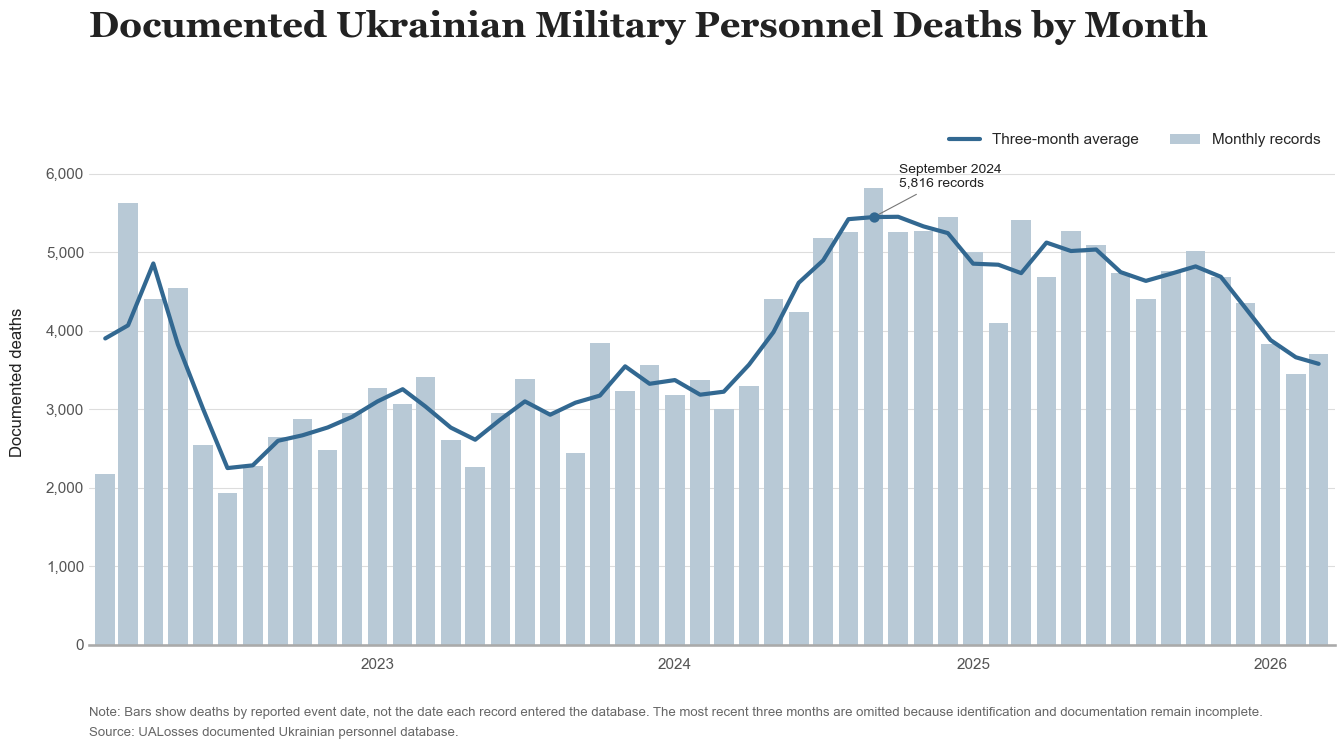

In [8]:
from matplotlib.ticker import StrMethodFormatter

ukr_timeline = ukr_database.copy()

ukr_timeline["event_date"] = pd.to_datetime(
    ukr_timeline["DateEvent"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

WAR_START = pd.Timestamp("2022-02-24")

ukr_timeline = ukr_timeline.loc[
    ukr_timeline["event_date"].notna()
    & (ukr_timeline["event_date"] >= WAR_START)
].copy()

ukr_timeline["month"] = (
    ukr_timeline["event_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

latest_date = ukr_timeline["event_date"].max()

cutoff_month = (
    latest_date.to_period("M") - 3
).to_timestamp()

ukr_timeline_complete = ukr_timeline.loc[
    ukr_timeline["month"] <= cutoff_month
].copy()

print("Latest event date:", latest_date.date())
print("Graph ends:", cutoff_month.strftime("%B %Y"))
print(
    "Records included:",
    f"{len(ukr_timeline_complete):,}"
)

monthly_deaths = (
    ukr_timeline_complete
    .groupby("month")
    .size()
)

complete_months = pd.date_range(
    start=WAR_START.to_period("M").to_timestamp(),
    end=cutoff_month,
    freq="MS"
)

monthly_deaths = monthly_deaths.reindex(
    complete_months,
    fill_value=0
)

rolling_deaths = monthly_deaths.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

peak_month = monthly_deaths.idxmax()
peak_value = monthly_deaths.max()

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

BAR_COLOR = "#b8c9d6"
LINE_COLOR = "#326891"
TEXT_COLOR = "#222222"
SECONDARY_TEXT = "#666666"
GRID_COLOR = "#dddddd"

fig, ax = plt.subplots(figsize=(14, 7.5))

ax.bar(
    monthly_deaths.index,
    monthly_deaths.values,
    width=24,
    color=BAR_COLOR,
    edgecolor="none",
    label="Monthly records"
)

ax.plot(
    rolling_deaths.index,
    rolling_deaths.values,
    color=LINE_COLOR,
    linewidth=3,
    label="Three-month average"
)

ax.scatter(
    peak_month,
    rolling_deaths.loc[peak_month],
    color=LINE_COLOR,
    s=35,
    zorder=5
)

ax.annotate(
    f"{peak_month.strftime('%B %Y')}\n{peak_value:,} records",
    xy=(
        peak_month,
        rolling_deaths.loc[peak_month]
    ),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=10,
    color=TEXT_COLOR,
    arrowprops={
        "arrowstyle": "-",
        "color": "#777777",
        "linewidth": 0.8
    }
)

ax.set_xlim(
    monthly_deaths.index.min() - pd.Timedelta(days=20),
    monthly_deaths.index.max() + pd.Timedelta(days=20)
)

ax.set_ylim(
    0,
    max(
        monthly_deaths.max(),
        rolling_deaths.max()
    ) * 1.15
)

ax.set_ylabel(
    "Documented deaths",
    labelpad=15,
    color=TEXT_COLOR
)

ax.set_xlabel("")

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#aaaaaa")

ax.tick_params(
    axis="y",
    length=0,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="major",
    length=0,
    pad=10,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    color="#bbbbbb"
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=11,
    ncol=2
)

fig.text(
    0.08,
    0.95,
    "Documented Ukrainian Military Personnel Deaths by Month",
    fontsize=26,
    fontweight="bold",
    fontfamily="Georgia",
    ha="left",
    color=TEXT_COLOR
)

fig.text(
    0.08,
    0.045,
    (
        "Note: Bars show deaths by reported event date, not the date each "
        "record entered the database. The most recent three months are omitted "
        "because identification and documentation remain incomplete."
    ),
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

fig.text(
    0.08,
    0.018,
    "Source: UALosses documented Ukrainian personnel database.",
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.84,
    bottom=0.14
)

plt.savefig(
    "figures/04_ukrainian_deaths_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Records with explicit death dates: 53,853
PMC records included: 5,040
Conscript records included: 4,048
Graph ends: January 2026


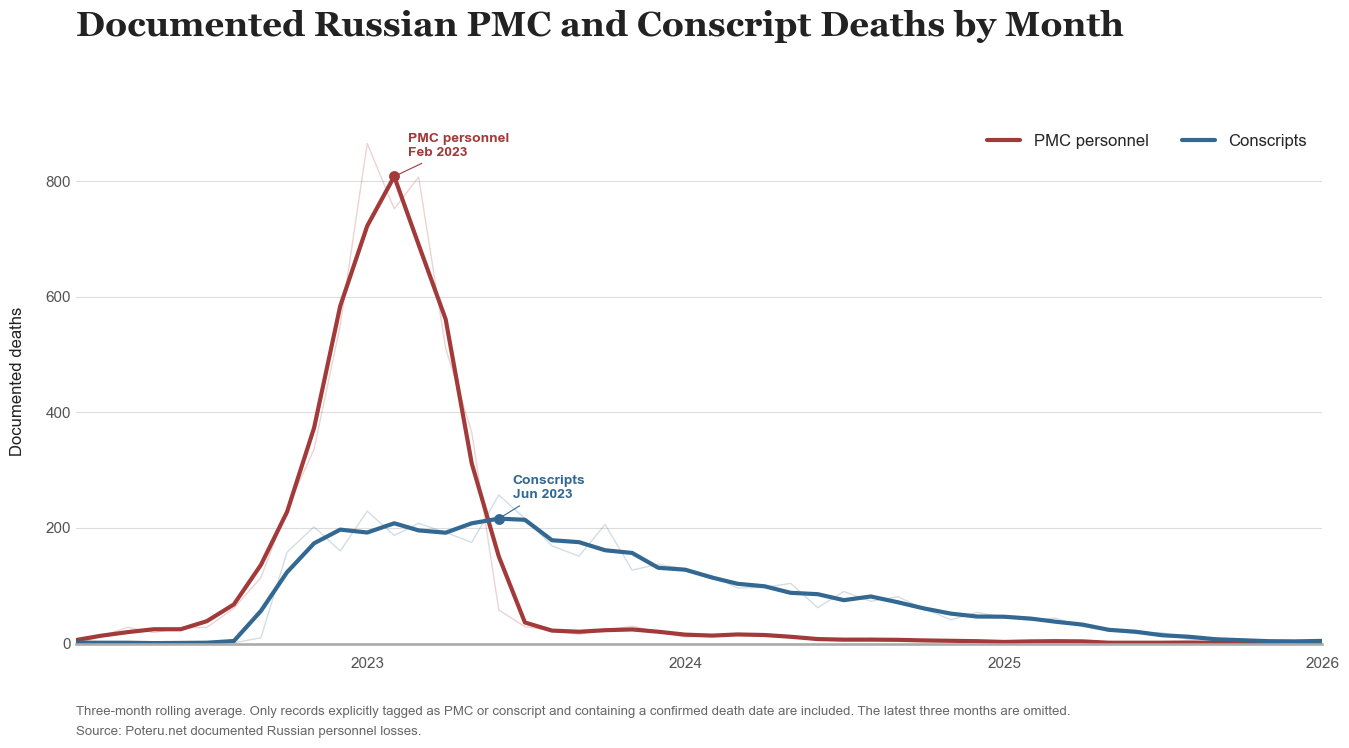

In [9]:
rus_categories = poteru.copy()

rus_categories["death_date"] = pd.to_datetime(
    rus_categories["Date_1"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

rus_categories["FlagPMC"] = (
    pd.to_numeric(
        rus_categories["FlagPMC"],
        errors="coerce"
    )
    .fillna(0)
    .eq(1)
)

rus_categories["FlagConscript"] = (
    pd.to_numeric(
        rus_categories["FlagConscript"],
        errors="coerce"
    )
    .fillna(0)
    .eq(1)
)

WAR_START = pd.Timestamp("2022-02-24")

rus_categories = rus_categories.loc[
    rus_categories["death_date"].notna()
    & (rus_categories["death_date"] >= WAR_START)
    & (rus_categories["DeathFlag"] == "DateDeath")
].copy()

rus_categories["month"] = (
    rus_categories["death_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

latest_date = rus_categories["death_date"].max()

cutoff_month = (
    latest_date.to_period("M") - 3
).to_timestamp()

rus_categories = rus_categories.loc[
    rus_categories["month"] <= cutoff_month
].copy()

print(
    "Records with explicit death dates:",
    f"{len(rus_categories):,}"
)

print(
    "PMC records included:",
    f"{rus_categories['FlagPMC'].sum():,}"
)

print(
    "Conscript records included:",
    f"{rus_categories['FlagConscript'].sum():,}"
)

print(
    "Graph ends:",
    cutoff_month.strftime("%B %Y")
)

complete_months = pd.date_range(
    start=WAR_START.to_period("M").to_timestamp(),
    end=cutoff_month,
    freq="MS"
)

monthly_categories = (
    rus_categories
    .groupby("month")[
        ["FlagPMC", "FlagConscript"]
    ]
    .sum()
    .reindex(
        complete_months,
        fill_value=0
    )
)

monthly_categories = monthly_categories.rename(
    columns={
        "FlagPMC": "PMC personnel",
        "FlagConscript": "Conscripts"
    }
)

# Three-month rolling averages
smoothed_categories = monthly_categories.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

PMC_COLOR = "#a33a3a"
CONSCRIPT_COLOR = "#326891"
TEXT_COLOR = "#222222"
SECONDARY_TEXT = "#666666"
GRID_COLOR = "#dddddd"

fig, ax = plt.subplots(figsize=(14, 7.5))

ax.plot(
    monthly_categories.index,
    monthly_categories["PMC personnel"],
    color=PMC_COLOR,
    linewidth=1,
    alpha=0.22
)

ax.plot(
    monthly_categories.index,
    monthly_categories["Conscripts"],
    color=CONSCRIPT_COLOR,
    linewidth=1,
    alpha=0.22
)

ax.plot(
    smoothed_categories.index,
    smoothed_categories["PMC personnel"],
    color=PMC_COLOR,
    linewidth=3,
    label="PMC personnel"
)

ax.plot(
    smoothed_categories.index,
    smoothed_categories["Conscripts"],
    color=CONSCRIPT_COLOR,
    linewidth=3,
    label="Conscripts"
)

for category, color in [
    ("PMC personnel", PMC_COLOR),
    ("Conscripts", CONSCRIPT_COLOR)
]:
    peak_month = smoothed_categories[category].idxmax()
    peak_value = smoothed_categories.loc[
        peak_month,
        category
    ]

    ax.scatter(
        peak_month,
        peak_value,
        color=color,
        s=40,
        zorder=5
    )

    ax.annotate(
        f"{category}\n{peak_month.strftime('%b %Y')}",
        xy=(peak_month, peak_value),
        xytext=(10, 15),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=color,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8
        }
    )

ax.set_xlim(
    monthly_categories.index.min(),
    monthly_categories.index.max()
)

ax.set_ylim(
    bottom=0
)

ax.set_ylabel(
    "Documented deaths",
    labelpad=15,
    color=TEXT_COLOR
)

ax.set_xlabel("")

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#aaaaaa")

ax.tick_params(
    axis="y",
    length=0,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="major",
    length=0,
    pad=10,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    color="#bbbbbb"
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=12,
    ncol=2
)

fig.text(
    0.08,
    0.95,
    "Documented Russian PMC and Conscript Deaths by Month",
    fontsize=25,
    fontweight="bold",
    fontfamily="Georgia",
    ha="left",
    color=TEXT_COLOR
)

fig.text(
    0.08,
    0.045,
    (
        "Three-month rolling average. Only records explicitly tagged as PMC "
        "or conscript and containing a confirmed death date are included. "
        "The latest three months are omitted."
    ),
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

fig.text(
    0.08,
    0.018,
    "Source: Poteru.net documented Russian personnel losses.",
    fontsize=9.5,
    ha="left",
    color=SECONDARY_TEXT
)

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.84,
    bottom=0.14
)

plt.savefig(
    "figures/05_russian_pmc_conscript_deaths.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Geocoded military reports: 303,927
Maximum active units: 171
Peak month: March 2022


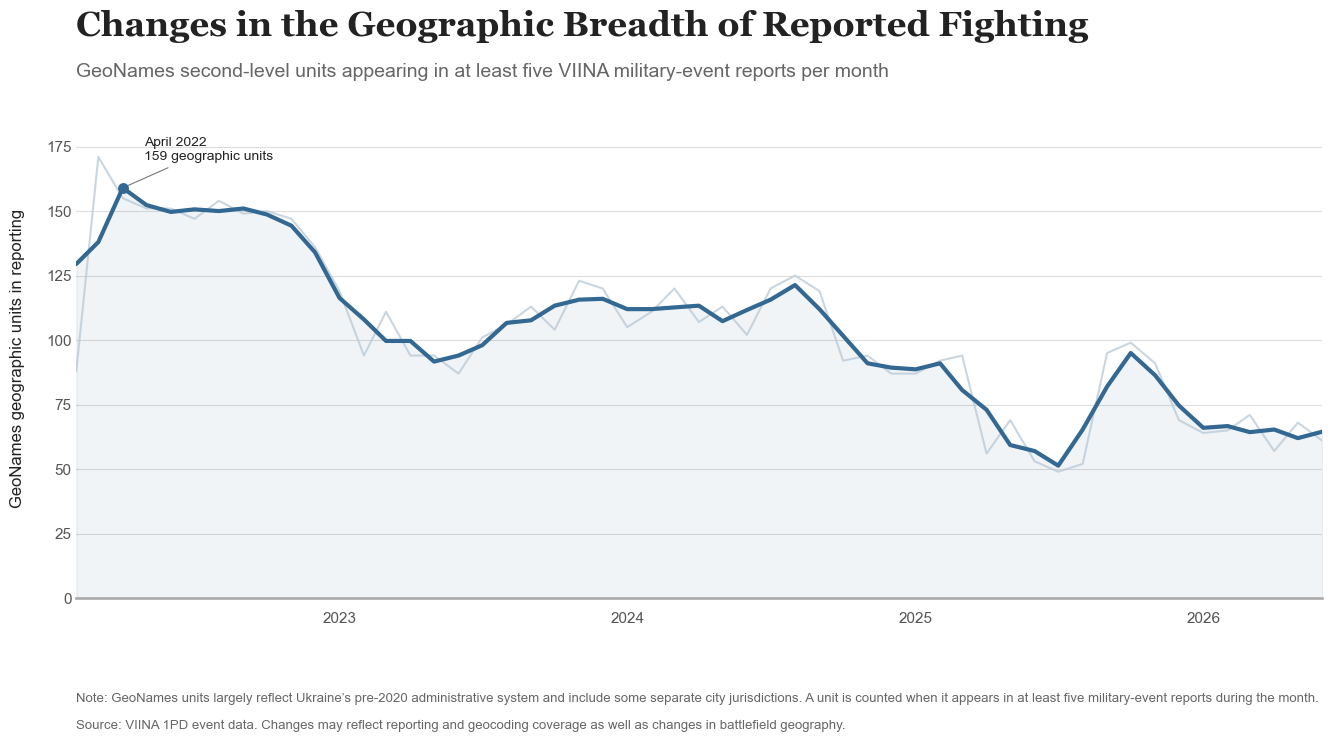

In [14]:
geographic_activity = events.copy()

if not pd.api.types.is_datetime64_any_dtype(
    geographic_activity["date"]
):
    geographic_activity["date"] = pd.to_datetime(
        geographic_activity["date"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True),
        format="%Y%m%d",
        errors="coerce"
    )

WAR_START = pd.Timestamp("2022-02-24")

geographic_activity = geographic_activity.loc[
    geographic_activity["date"].notna()
    & (geographic_activity["date"] >= WAR_START)
].copy()

geographic_activity["t_mil_b"] = (
    pd.to_numeric(
        geographic_activity["t_mil_b"],
        errors="coerce"
    )
    .fillna(0)
    .gt(0.5)
)

geographic_activity = geographic_activity.loc[
    geographic_activity["t_mil_b"]
].copy()

geographic_activity["month"] = (
    geographic_activity["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

geographic_activity["ADM2_CODE"] = pd.to_numeric(
    geographic_activity["ADM2_CODE"],
    errors="coerce"
)

geographic_activity = geographic_activity.loc[
    geographic_activity["ADM2_CODE"].notna()
].copy()

latest_month = (
    geographic_activity["date"]
    .max()
    .to_period("M")
    .to_timestamp()
)

geographic_activity = geographic_activity.loc[
    geographic_activity["month"] < latest_month
].copy()

unit_month_counts = (
    geographic_activity
    .groupby(["month", "ADM2_CODE"])
    .size()
    .rename("reports")
    .reset_index()
)

MIN_UNIT_REPORTS = 5

active_units = (
    unit_month_counts.loc[
        unit_month_counts["reports"]
        >= MIN_UNIT_REPORTS
    ]
    .groupby("month")["ADM2_CODE"]
    .nunique()
)

all_months = pd.date_range(
    start=WAR_START.to_period("M").to_timestamp(),
    end=geographic_activity["month"].max(),
    freq="MS"
)

active_units = active_units.reindex(
    all_months,
    fill_value=0
)

active_units_smoothed = active_units.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

print(
    "Geocoded military reports:",
    f"{len(geographic_activity):,}"
)

print(
    "Maximum active units:",
    active_units.max()
)

print(
    "Peak month:",
    active_units.idxmax().strftime("%B %Y")
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

LINE_COLOR = "#326891"
RAW_COLOR = "#b8c9d6"
TEXT_COLOR = "#222222"
SECONDARY_TEXT = "#666666"
GRID_COLOR = "#dddddd"

fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

ax.plot(
    active_units.index,
    active_units.values,
    color=RAW_COLOR,
    linewidth=1.5,
    alpha=0.75
)

ax.plot(
    active_units_smoothed.index,
    active_units_smoothed.values,
    color=LINE_COLOR,
    linewidth=3
)

ax.fill_between(
    active_units_smoothed.index,
    active_units_smoothed.values,
    0,
    color=LINE_COLOR,
    alpha=0.07
)

peak_month = active_units_smoothed.idxmax()
peak_value = active_units_smoothed.max()

ax.scatter(
    peak_month,
    peak_value,
    color=LINE_COLOR,
    s=40,
    zorder=5
)

ax.annotate(
    (
        f"{peak_month.strftime('%B %Y')}\n"
        f"{peak_value:.0f} geographic units"
    ),
    xy=(peak_month, peak_value),
    xytext=(15, 20),
    textcoords="offset points",
    fontsize=10,
    color=TEXT_COLOR,
    arrowprops={
        "arrowstyle": "-",
        "color": "#777777",
        "linewidth": 0.8
    }
)

ax.set_xlim(
    active_units.index.min(),
    active_units.index.max()
)

ax.set_ylim(
    0,
    active_units_smoothed.max() * 1.17
)

ax.set_ylabel(
    "GeoNames geographic units in reporting",
    labelpad=15,
    color=TEXT_COLOR
)

ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#aaaaaa")

ax.tick_params(
    axis="y",
    length=0,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="major",
    length=0,
    pad=10,
    colors="#555555"
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    color="#bbbbbb"
)

fig.text(
    0.08,
    0.95,
    "Changes in the Geographic Breadth of Reported Fighting",
    fontsize=25,
    fontweight="bold",
    fontfamily="Georgia",
    ha="left",
    color=TEXT_COLOR
)

fig.text(
    0.08,
    0.895,
    (
        "GeoNames second-level units appearing in at least five "
        "VIINA military-event reports per month"
    ),
    fontsize=14,
    ha="left",
    color=SECONDARY_TEXT
)

note_text = (
    "Note: GeoNames units largely reflect Ukraine’s pre-2020 administrative "
    "system and include some separate city jurisdictions. A unit is counted "
    "when it appears in at least five military-event reports during the month."
)

source_text = (
    "Source: VIINA 1PD event data. Changes may reflect reporting and geocoding "
    "coverage as well as changes in battlefield geography."
)

fig.text(
    0.08,
    0.075,
    note_text,
    fontsize=9.5,
    ha="left",
    va="top",
    color=SECONDARY_TEXT,
    wrap=True
)

fig.text(
    0.08,
    0.038,
    source_text,
    fontsize=9.5,
    ha="left",
    va="top",
    color=SECONDARY_TEXT,
    wrap=True
)

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.84,
    bottom=0.20
)

plt.savefig(
    "figures/08_viina_geographic_spread.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()